# MDR-TS v1.0
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Thu Jan 8th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v1.0
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Macbook M2 Pro

---

## What's new?

Fixed the feature leak.

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [3]:
# Project paths
VERSION = "v1"
SUBVERSION = "v1.0"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR/"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR/
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR//Models/Temporal/v1/v1.0

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [14]:
from pathlib import Path

# Split file paths
TRAIN_PATH = str(Path(SPLIT_ROOT) / "base_no_met/train_base_no_met.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "base_no_met/val_base_no_met.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "base_no_met/test_base_no_met.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

# Load
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Parse date
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if "date" in d.columns:
        d["date"] = pd.to_datetime(d["date"], errors="coerce")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/base_no_met/train_base_no_met.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/base_no_met/val_base_no_met.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/base_no_met/test_base_no_met.csv

train: shape=(15904, 16)
train: columns=16

val: shape=(3408, 16)
val: columns=16

test: shape=(3408, 16)
test: columns=16


In [15]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 16

columns:
['station_id', 'date', 'longitude', 'latitude', 'rain_mm', 'precip_mm', 'NDVI', 'NDMI', 'MSI', 's1_vv', 's1_vh', 'SAR_ratio', 'elev', 'slope', 'DOY', 'soil_moisture_5cm']


## 4. Data Sanity Checks

In [30]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    "rain_mm",
    "precip_mm",
    "NDVI",
    "NDMI",
    "MSI",
    "s1_vv",
    "s1_vh",
    "SAR_ratio",
    # "elev",
    # "slope",
    "DOY",
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 9
  Target:   soil_moisture_5cm


In [31]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[OK] station Touchet_WA_824: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [32]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-08-17 00:00:00
    val   min date: 2021-08-18 00:00:00
  Station Quinault:
    train max date: 2021-09-03 00:00:00
    val   min date: 2021-09-04 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-05-13 00:00:00
    val   min date: 2021-05-14 00:00:00
  Station Spokane:
    train max date: 2021-09-19 00:00:00
    val   min date: 2021-09-20 00:00:00
  Station Touchet_WA_824:
    train max date: 2018-06-07 00:00:00
    val   min date: 2018-06-08 00:00:00


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [33]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     15904
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-19 00:00:00

VAL
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2018-06-08 00:00:00 -- 2023-12-29 00:00:00

TEST
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2019-11-12 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [34]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (15904, 9)
  X_val:   (3408, 9)
  X_test:  (3408, 9)
  y_train: (15904,)


### 6.2 Feature Overview

In [35]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
DOY,185.023893,103.325581,1.000000,366.000000
precip_mm,4.440726,9.805408,0.000000,127.600000
rain_mm,3.289946,8.651461,0.000000,127.600000
SAR_ratio,4.870107,0.941622,2.420880,7.880614
MSI,0.767842,0.232434,0.090847,1.294773
NDVI,0.321557,0.186608,-0.006336,0.887444
NDMI,0.151717,0.158200,-0.128454,0.833438
s1_vv,0.100264,0.047048,0.035328,0.286763
s1_vh,0.022109,0.011958,0.005213,0.073972


### 6.3 Feature Correlation

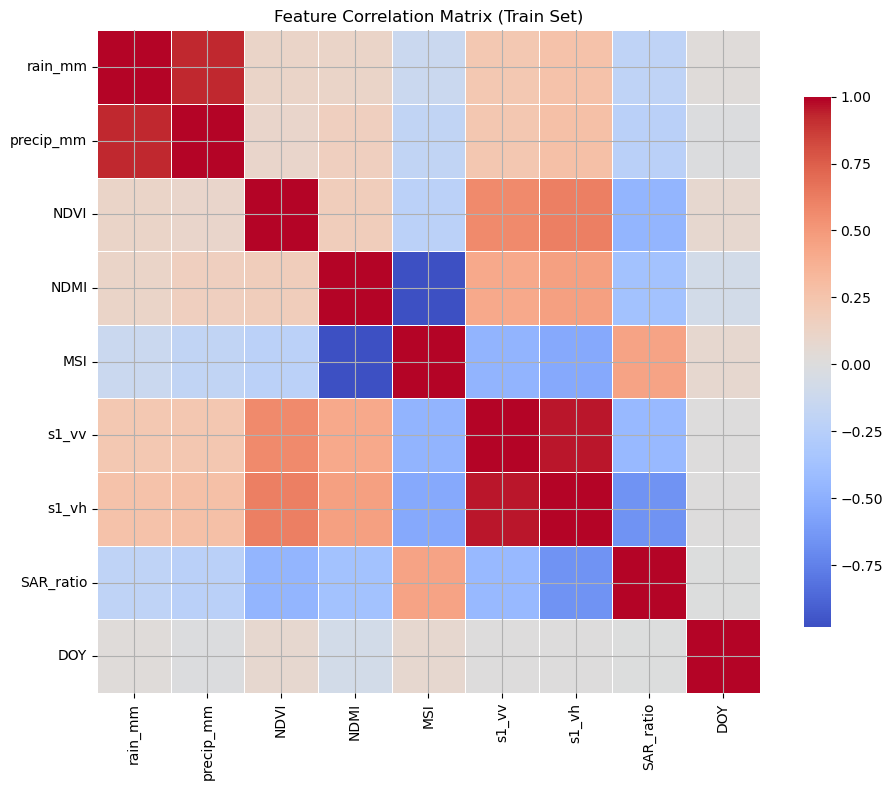

In [36]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### 6.4 Baseline Model Definition

In [37]:
MODEL_CONFIG = {
    "n_estimators": 500,          # upper bound, early stopping will cap it
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
}

print("MODEL_CONFIG:")
for k, v in MODEL_CONFIG.items():
    print(f"  {k}: {v}")

MODEL_CONFIG:
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.0
  reg_lambda: 1.0
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1


In [38]:
model = XGBRegressor(**MODEL_CONFIG)
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)


### 6.5 Feature Importance

In [50]:
# scaffolded for now

## 7. Training Loop

### 7.1 Fit Model

In [39]:
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

print("Training complete")

[0]	validation_0-rmse:0.09853	validation_1-rmse:0.10444
[50]	validation_0-rmse:0.05010	validation_1-rmse:0.06681
[100]	validation_0-rmse:0.04420	validation_1-rmse:0.06502
[150]	validation_0-rmse:0.04199	validation_1-rmse:0.06506
[200]	validation_0-rmse:0.04051	validation_1-rmse:0.06548
[250]	validation_0-rmse:0.03931	validation_1-rmse:0.06578
[300]	validation_0-rmse:0.03831	validation_1-rmse:0.06606
[350]	validation_0-rmse:0.03743	validation_1-rmse:0.06631
[400]	validation_0-rmse:0.03664	validation_1-rmse:0.06649
[450]	validation_0-rmse:0.03600	validation_1-rmse:0.06683
[499]	validation_0-rmse:0.03541	validation_1-rmse:0.06678
Training complete


### 7.2 Predictions

In [40]:
yhat_train = model.predict(X_train)
yhat_val   = model.predict(X_val)
yhat_test  = model.predict(X_test)

print("Predictions generated")
print("  yhat_train:", yhat_train.shape)
print("  yhat_val:  ", yhat_val.shape)
print("  yhat_test: ", yhat_test.shape)

Predictions generated
  yhat_train: (15904,)
  yhat_val:   (3408,)
  yhat_test:  (3408,)


### 7.3 Metrics

In [41]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

results = pd.DataFrame([
    metrics_block("train", y_train, yhat_train),
    metrics_block("val",   y_val,   yhat_val),
    metrics_block("test",  y_test,  yhat_test),
])

results

,split,MAE,RMSE,R2
0,train,0.024815,0.035413,0.879066
1,val,0.050936,0.066775,0.613661
2,test,0.049829,0.064362,0.520847


### 7.4 Diagnostics

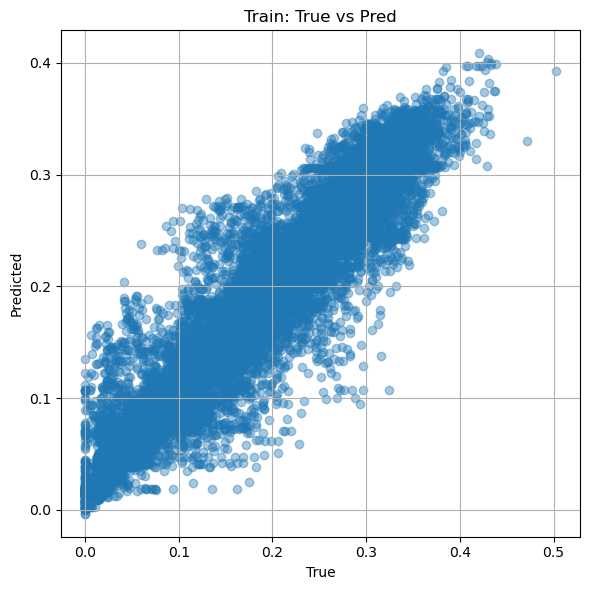

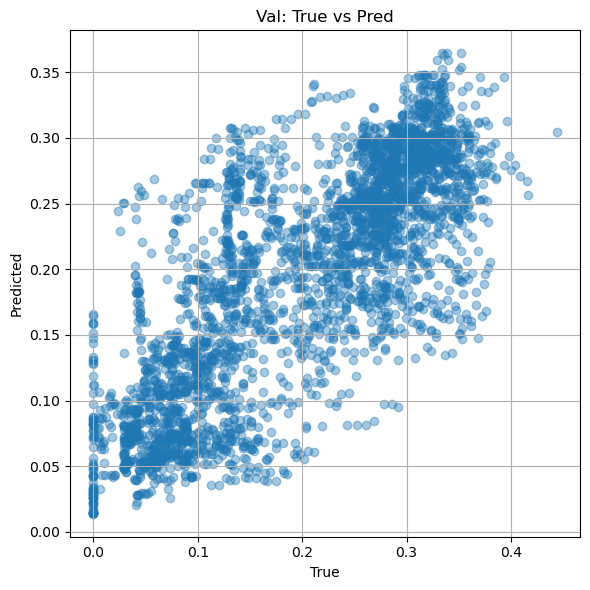

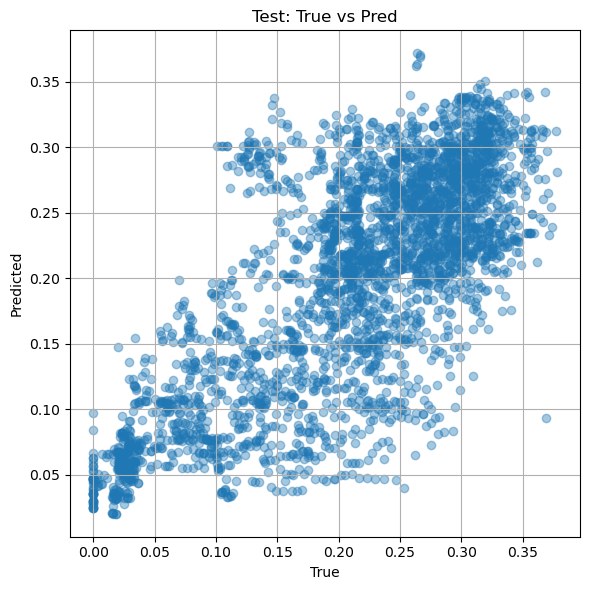

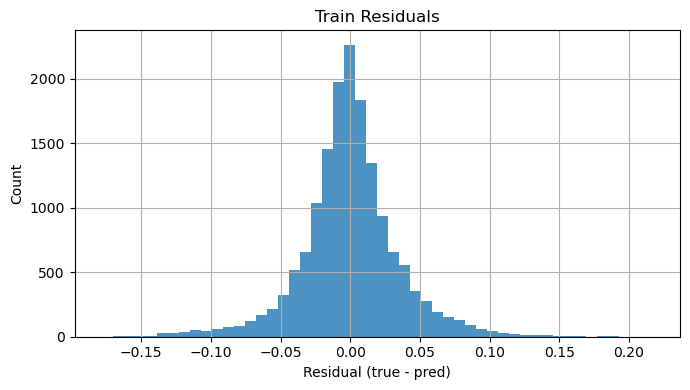

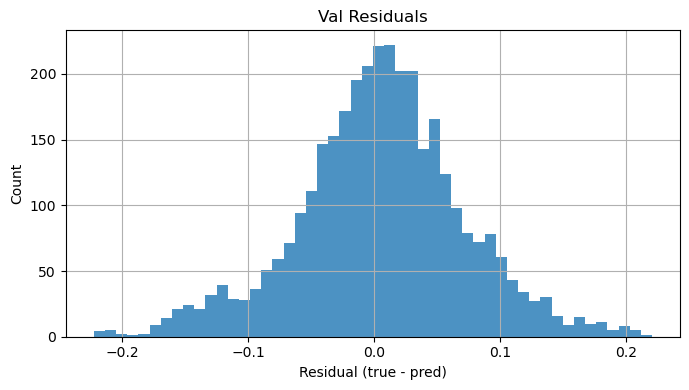

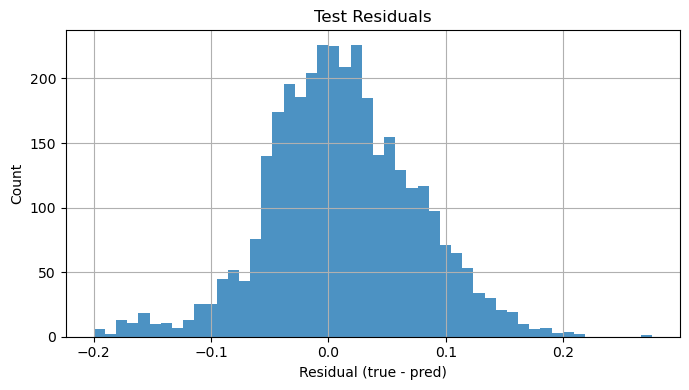

In [42]:
def scatter_plot(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def residual_hist(y_true, y_pred, title):
    resid = y_true.values - y_pred
    plt.figure(figsize=(7, 4))
    plt.hist(resid, bins=50, alpha=0.8)
    plt.xlabel("Residual (true - pred)")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

scatter_plot(y_train, yhat_train, "Train: True vs Pred")
scatter_plot(y_val,   yhat_val,   "Val: True vs Pred")
scatter_plot(y_test,  yhat_test,  "Test: True vs Pred")

residual_hist(y_train, yhat_train, "Train Residuals")
residual_hist(y_val,   yhat_val,   "Val Residuals")
residual_hist(y_test,  yhat_test,  "Test Residuals")

# MAKE IT A PANEL 3 cols 2 rows

### 7.5 Feature Importance

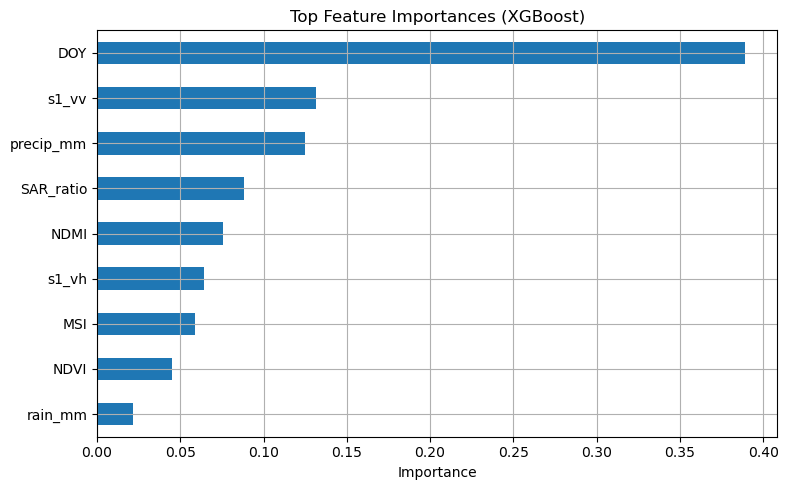

DOY          0.388990
s1_vv        0.131505
precip_mm    0.124959
SAR_ratio    0.088343
NDMI         0.075899
s1_vh        0.064519
MSI          0.058901
NDVI         0.044990
rain_mm      0.021894
dtype: float32

In [43]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Validation

### 8.1 Best Iteration & Early Stopping Behavior

In [44]:
if hasattr(model, "best_iteration"):
    print("Best boosting iteration:", model.best_iteration)
    print("Best validation score:", model.best_score)
else:
    print("Model was trained without early stopping.")

Model was trained without early stopping.


### 8.2 Validation Error by Time

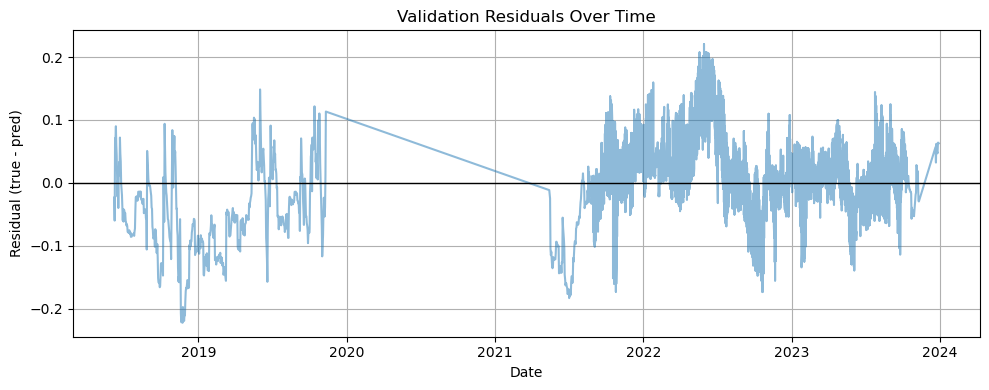

In [45]:
val_analysis = val_df.copy()
val_analysis["y_true"] = y_val.values
val_analysis["y_pred"] = yhat_val
val_analysis["residual"] = val_analysis["y_true"] - val_analysis["y_pred"]

# sort by time
val_analysis = val_analysis.sort_values("date")

plt.figure(figsize=(10, 4))
plt.plot(val_analysis["date"], val_analysis["residual"], alpha=0.5)
plt.axhline(0, color="black", linewidth=1)
plt.title("Validation Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual (true - pred)")
plt.tight_layout()
plt.show()

### 8.3 Validation Metrics by Station

In [46]:
def station_metrics(d):
    rows = []
    for sid, g in d.groupby("station_id"):
        rows.append({
            "station_id": sid,
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "RMSE": rmse(g["y_true"], g["y_pred"]),
            "R2": r2_score(g["y_true"], g["y_pred"]),
            "n": len(g),
        })
    return pd.DataFrame(rows)

val_station_metrics = station_metrics(val_analysis)
val_station_metrics

,station_id,MAE,RMSE,R2,n
0,Darrington,0.057958,0.075590,0.608544,735
1,Quinault,0.044633,0.057441,0.391760,762
2,SourdoughGulch_WA_985,0.049122,0.066486,0.587038,751
3,Spokane,0.037308,0.049497,0.787274,638
4,Touchet_WA_824,0.069519,0.083037,0.047357,522


### 8.4 Validation Residual Distribution

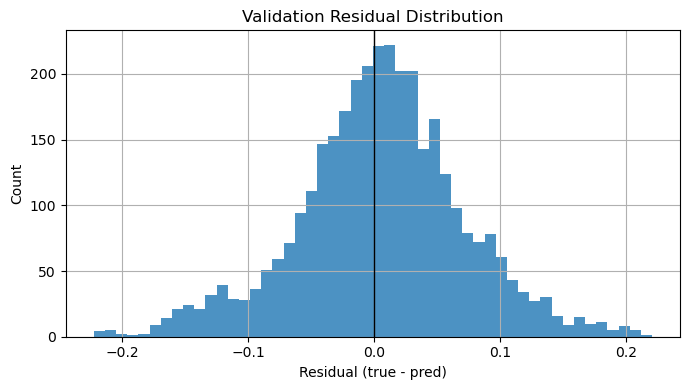

In [47]:
plt.figure(figsize=(7, 4))
plt.hist(val_analysis["residual"], bins=50, alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Residual (true - pred)")
plt.ylabel("Count")
plt.title("Validation Residual Distribution")
plt.tight_layout()
plt.show()

## 9. Evaluation

### 9.1 Test Metrics

In [48]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test),
    "RMSE": rmse(y_test, yhat_test),
    "R2":   r2_score(y_test, yhat_test),
    "n":    len(y_test),
    "station_id": sorted(test_df["station_id"].unique().tolist()),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n,station_id
0,0.049829,0.064362,0.520847,3408,"[Darrington, Quinault, SourdoughGulch_WA_985, ..."


### 9.2 Test Prediction Scatter

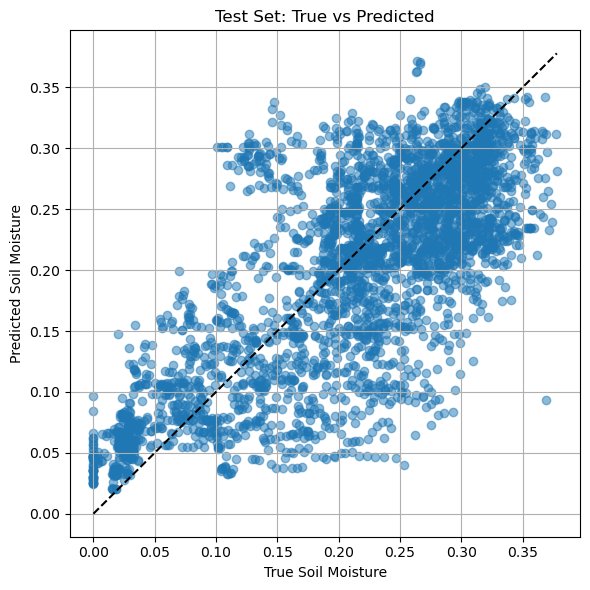

In [49]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 9.3 Test Residuals Over Time

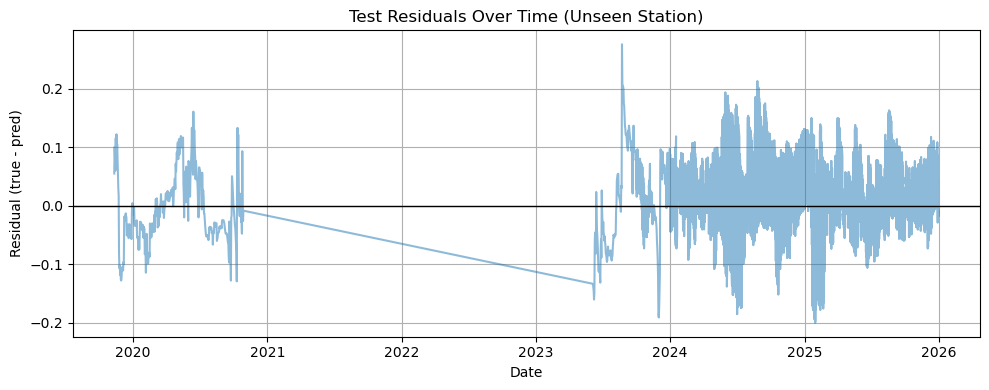

In [50]:
test_analysis = test_df.copy()
test_analysis["y_true"] = y_test.values
test_analysis["y_pred"] = yhat_test
test_analysis["residual"] = test_analysis["y_true"] - test_analysis["y_pred"]

test_analysis = test_analysis.sort_values("date")

plt.figure(figsize=(10, 4))
plt.plot(test_analysis["date"], test_analysis["residual"], alpha=0.5)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Residual (true - pred)")
plt.title("Test Residuals Over Time (Unseen Station)")
plt.tight_layout()
plt.show()

### 9.4 Test Residual Distribution

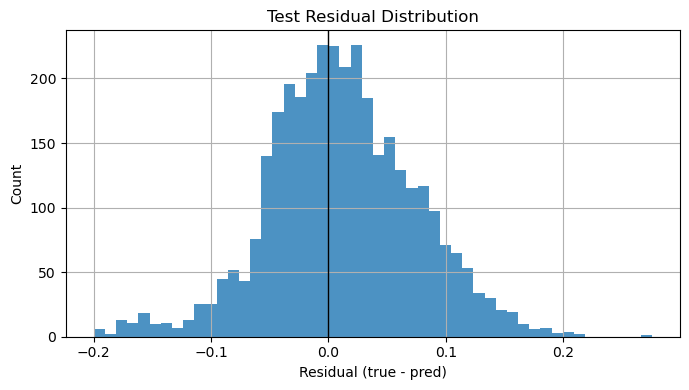

In [51]:
plt.figure(figsize=(7, 4))
plt.hist(test_analysis["residual"], bins=50, alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Residual (true - pred)")
plt.ylabel("Count")
plt.title("Test Residual Distribution")
plt.tight_layout()
plt.show()

### 9.5 Bias

In [52]:
print("VAL residual mean: ", float((y_val.values - yhat_val).mean()))
print("TEST residual mean:", float((y_test.values - yhat_test).mean()))
print("VAL pred range:    ", float(yhat_val.min()), "-->", float(yhat_val.max()))
print("TEST pred range:   ", float(yhat_test.min()), "-->", float(yhat_test.max()))

VAL residual mean:  0.0050032075516586606
TEST residual mean: 0.011728150278015034
VAL pred range:     0.013900628313422203 --> 0.36445868015289307
TEST pred range:    0.020360192283988 --> 0.3718169033527374


## 10. Metrics & Visalization

### 10.1 Consolidated Metrics
Summary of core regression metrics across all dataset splits

In [53]:
results = results.copy()  # from Section 7

results = results.set_index("split").loc[["train", "val", "test"]]
results

,MAE,RMSE,R2
split,,,
train,0.024815,0.035413,0.879066
val,0.050936,0.066775,0.613661
test,0.049829,0.064362,0.520847


### 10.2 Generalization Gap

In [54]:
gap = {
    "train -> val (MAE)": results.loc["val", "MAE"] - results.loc["train", "MAE"],
    "val -> test (MAE)":  results.loc["test", "MAE"] - results.loc["val", "MAE"],
}

pd.DataFrame.from_dict(gap, orient="index", columns=["delta_MAE"])

,delta_MAE
train -> val (MAE),0.026122
val -> test (MAE),-0.001107


### 10.3 Feature Importance Recap

In [55]:
importances.head(10)

DOY          0.388990
s1_vv        0.131505
precip_mm    0.124959
SAR_ratio    0.088343
NDMI         0.075899
s1_vh        0.064519
MSI          0.058901
NDVI         0.044990
rain_mm      0.021894
dtype: float32

## 11. Save Artifacts

In [56]:
from datetime import datetime

RUN_NAME = "mdr_ts_v2_3"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v1/v1.0/mdr_ts_v2_3_20260108_115420


In [57]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")
model.save_model(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v1/v1.0/mdr_ts_v2_3_20260108_115420/model.json


In [58]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": MODEL_CONFIG,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v1/v1.0/mdr_ts_v2_3_20260108_115420/run_metadata.json


In [59]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v1/v1.0/mdr_ts_v2_3_20260108_115420/metrics.csv


In [60]:
IMPORTANCE_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
importances.to_csv(IMPORTANCE_PATH, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v1/v1.0/mdr_ts_v2_3_20260108_115420/feature_importance.csv


In [61]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

## 12. Notes & Experiments

Train models with one feature removed at a time to identify which features harm or help generalization

In [76]:
from copy import deepcopy

def train_and_eval(feature_cols, label, model_config):
    Xtr = train_df[feature_cols]
    Xva = val_df[feature_cols]
    Xte = test_df[feature_cols]

    ytr = train_df[TARGET_COL]
    yva = val_df[TARGET_COL]
    yte = test_df[TARGET_COL]

    m = XGBRegressor(**deepcopy(model_config))
    m.fit(Xtr, ytr, verbose=False)

    p_tr = m.predict(Xtr)
    p_va = m.predict(Xva)
    p_te = m.predict(Xte)

    out = {
        "label": label,
        "n_features": len(feature_cols),
        "features": feature_cols,

        "train_MAE": float(mean_absolute_error(ytr, p_tr)),
        "train_RMSE": float(np.sqrt(mean_squared_error(ytr, p_tr))),
        "train_R2": float(r2_score(ytr, p_tr)),

        "val_MAE": float(mean_absolute_error(yva, p_va)),
        "val_RMSE": float(np.sqrt(mean_squared_error(yva, p_va))),
        "val_R2": float(r2_score(yva, p_va)),
        "val_bias_mean_resid": float((yva.values - p_va).mean()),

        "test_MAE": float(mean_absolute_error(yte, p_te)),
        "test_RMSE": float(np.sqrt(mean_squared_error(yte, p_te))),
        "test_R2": float(r2_score(yte, p_te)),
        "test_bias_mean_resid": float((yte.values - p_te).mean()),
    }
    return out, m

# Run baseline + leave-one-out
ABLATION_RESULTS = []

# Baseline
base_res, _ = train_and_eval(FEATURE_COLS, "BASELINE", MODEL_CONFIG)
ABLATION_RESULTS.append(base_res)

# Leave-one-feature-out
for feat in FEATURE_COLS:
    cols = [c for c in FEATURE_COLS if c != feat]
    res, _ = train_and_eval(cols, f"DROP_{feat}", MODEL_CONFIG)
    ABLATION_RESULTS.append(res)

ablation_df = pd.DataFrame(ABLATION_RESULTS)

# Add deltas vs baseline (test + val)
for col in ["val_MAE", "test_MAE", "val_RMSE", "test_RMSE", "val_R2", "test_R2", "val_bias_mean_resid", "test_bias_mean_resid"]:
    ablation_df[f"delta_{col}"] = ablation_df[col] - base_res[col]

# Sort by test MAE improvement (most negative delta is best)
ablation_df_sorted = ablation_df.sort_values("delta_test_MAE", ascending=True).reset_index(drop=True)

ablation_df_sorted[[
    "label", "n_features",
    "val_MAE", "delta_val_MAE",
    "test_MAE", "delta_test_MAE",
    "test_R2", "delta_test_R2",
    "test_bias_mean_resid", "delta_test_bias_mean_resid"
]].head(15)

,label,n_features,val_MAE,delta_val_MAE,test_MAE,delta_test_MAE,test_R2,delta_test_R2,test_bias_mean_resid,delta_test_bias_mean_resid
0,DROP_DOY,13,0.045965,0.010705,0.064540,-0.003471,0.017134,0.091043,-0.052046,-0.001787
1,DROP_rh_mean,13,0.040237,0.004977,0.065496,-0.002515,-0.011775,0.062134,-0.041129,0.009129
2,BASELINE,14,0.035261,0.000000,0.068011,0.000000,-0.073909,0.000000,-0.050259,0.000000
3,DROP_solar_radiation,13,0.037232,0.001971,0.068626,0.000616,-0.104210,-0.030301,-0.049166,0.001093
4,DROP_rain_mm,13,0.035915,0.000654,0.068752,0.000741,-0.102168,-0.028259,-0.050788,-0.000529
5,DROP_NDVI,13,0.034270,-0.000991,0.069092,0.001081,-0.102955,-0.029046,-0.052832,-0.002574
6,DROP_air_temp_mean,13,0.035139,-0.000122,0.070081,0.002070,-0.144365,-0.070456,-0.052402,-0.002143
7,DROP_precip_mm,13,0.035725,0.000464,0.070130,0.002120,-0.137318,-0.063410,-0.051862,-0.001604
8,DROP_NDMI,13,0.035299,0.000039,0.070222,0.002212,-0.148116,-0.074207,-0.053378,-0.003119
9,DROP_s1_vh,13,0.035248,-0.000013,0.070542,0.002531,-0.176175,-0.102266,-0.053558,-0.003299


In [77]:
ablation_df_sorted.iloc[:10][
    ["label", "delta_test_MAE", "delta_test_R2", "delta_test_bias_mean_resid", "test_MAE", "test_R2", "test_bias_mean_resid"]
]

,label,delta_test_MAE,delta_test_R2,delta_test_bias_mean_resid,test_MAE,test_R2,test_bias_mean_resid
0,DROP_DOY,-0.003471,0.091043,-0.001787,0.064540,0.017134,-0.052046
1,DROP_rh_mean,-0.002515,0.062134,0.009129,0.065496,-0.011775,-0.041129
2,BASELINE,0.000000,0.000000,0.000000,0.068011,-0.073909,-0.050259
3,DROP_solar_radiation,0.000616,-0.030301,0.001093,0.068626,-0.104210,-0.049166
4,DROP_rain_mm,0.000741,-0.028259,-0.000529,0.068752,-0.102168,-0.050788
5,DROP_NDVI,0.001081,-0.029046,-0.002574,0.069092,-0.102955,-0.052832
6,DROP_air_temp_mean,0.002070,-0.070456,-0.002143,0.070081,-0.144365,-0.052402
7,DROP_precip_mm,0.002120,-0.063410,-0.001604,0.070130,-0.137318,-0.051862
8,DROP_NDMI,0.002212,-0.074207,-0.003119,0.070222,-0.148116,-0.053378
9,DROP_s1_vh,0.002531,-0.102266,-0.003299,0.070542,-0.176175,-0.053558


### Ablation Summary

This ablation did *exactly* what it was supposed to do. The baseline model fits the training stations extremely well and generalizes reasonably in time, but it struggles when asked to generalize to a completely unseen station. That failure is not random noise, it is systematic bias, and the ablation clearly identifies where that bias is coming from.

The biggest and cleanest result is **DOY**. Dropping `DOY` improves test MAE by ~0.0035 and flips test R² from negative to slightly positive. That is a real improvement, not a rounding error. What this tells us is that `DOY` is acting as a strong seasonal prior that works well for stations the model has already seen, but hurts spatial generalization. In other words, the model is learning *calendar shortcuts* instead of relying purely on physical signals.

A secondary but still meaningful result is `rh_mean`. Removing relative humidity slightly improves test MAE and, more importantly, reduces the negative bias on the unseen station. This suggests RH is partially encoding station-specific climate regimes rather than transferable soil moisture dynamics. It is not as problematic as `DOY`, but it is definitely something to be cautious about.

Interestingly, **elevation is not the villain**. Dropping `elev` makes test performance significantly worse across all metrics. That means elevation is providing real, physically meaningful signal. The earlier concern was not elevation itself, but the interaction between elevation and global priors like `DOY`. Removing the calendar prior fixes the anchoring issue without throwing away useful geography.

The SAR and vegetation features (`VV`, `VH`, `SAR_ratio`, `NDMI`, `MSI`) all behave well. Dropping any of them degrades test performance, which is good news. It means the model is actually learning from remotely sensed surface information rather than just climate averages.

One important observation is that removing `DOY` *hurts validation MAE* while improving test MAE. This is expected and not a bug. Validation measures temporal generalization on known stations, while test measures spatial generalization. `DOY` helps with the former and hurts the latter. Since the goal of MDR is station-invariant modeling, the test behavior is the one that matters more at this stage.

**Concrete takeaway:**  
For the next version, `DOY` should be removed. `rh_mean` is optional but suspicious. Elevation should stay. SAR + vegetation features are doing real work and should be kept.

The clean next step is to define **MDR-TS v1.1** as the same model, same split, same config, but with `DOY` removed from `FEATURE_COLS`. No new features, no hyperparameter tuning yet. Just fix the structural issue first, then iterate.

---

_Jakob Balkovec_